# Install Packages

In [39]:
import re
import json
import os
from pathlib import Path
from datetime import datetime

from pprint import pprint
from __future__ import annotations
from IPython.display import Image
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

# Import typing helpers for type hints 
from typing import TypedDict, Dict, List, Literal, Optional, Any

# BaseModel is the core class used to define structured data models 
from pydantic import BaseModel, Field, ConfigDict, model_validator, ValidationError

In [40]:
# Import schemas
from schemas.content_blueprint import ContentBlueprint
from schemas.style_profile import StyleProfileStructure
from schemas.reflection_blueprint import ReflectionBlueprint

# Load API Key

In [41]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [42]:
api_key = os.getenv("OPENAI_API_KEY")

# Load Output from Previous Agent (Content Outline)

In [43]:
# Simulate this by loading the mock data json
with open("mocks/mock_content_blueprint.json", "r") as f:
    content_outline = json.load(f)

pprint(content_outline)

{'big_idea': 'Artificial intelligence will be a defining technology of our '
             'era, and Singapore must harness it to raise productivity, '
             'strengthen competitiveness, and create better opportunities for '
             'all Singaporeans.',
 'hook': {'description': 'Open by highlighting how AI has rapidly evolved from '
                         'a distant concept to an integral part of everyday '
                         'life in Singapore, touching on familiar examples '
                         "that resonate with the audience's experience today, "
                         'setting the stage for why this matters to all '
                         'Singaporeans now and in the future, especially at '
                         'this National Day Rally moment of reflection and '
                         'progress discussion.',
          'type': 'observation'},
 'ted_sections': [{'id': 'TS1',
                   'must_include_facts': ['In 2020, AI struggled to solve '

## (Optional) Validate Schema to ensure previous output is valid for use
To discuss: Actually I feel that it is better to assume that the previous agent has already validated its output to be correct before passing it down, so that we dont need to do double validation here. 
* If the previous agent validate its own output and it's wrong, it can repeatedly correct itself
* If the downstream validate for the upstream then in between EACH upstream and downstream we have to create maker-checker loops, which doesnt make sense.
* Proposed approach: Each agent validate its own final output, before sending to downstream. Downstream agent takes it that output is correct. 

In [ ]:
# if success, outputs a structured Python object with validated, typed data
try: 
    content_instance = ContentBlueprint.model_validate(content_outline)
except ValidationError as e: 
    validation_error = e
    pprint(validation_error.errors())

# Define SpeechScript State
This state same as the one in our repo, so that my development is aligned immediately (no double work). I only included the state fields that I am working with.

In [44]:
# Import schemas for the State (these will be part of state.py but for convenience sake load it here)
from schemas.content_blueprint import ContentBlueprint

class SpeechScriptState(TypedDict):
    # Other fields...
    content_blueprint: ContentBlueprint

    chunk_style_notes: List[Dict[str, Any]] # Newly added field so Style Extraction Agent can pass info to Style Aggregation Agent. 
    style_profile: Dict[str, Any] # Newly added field so Style Aggregation Agent can pass info to Script Writing Agent. Dict of str format as it is not critical to adhere to JSON structure for this field
    stylistic_script: str 

    # Feedback fields...

    style_feedback: ReflectionBlueprint
    style_approved: bool
    style_reviews: int # Change name for clarity

# Overall Approach
* agent 1: chunk docs and analyse rhetoric style per chunk
* agent 2: read all rhetoric styles for all chunks and generalise to 1 style profile
* agent 3: write the script based on the style profile

Justification
* Better modularity: chunk analysis and style generalization are different tasks
* separation makes debugging easier
* Higher controllability: Can inspect per-chunk outputs before synthesis

# Create Style Extraction Agent

This agent works by 
1. loading the style samples (assume max 5 documents) and chunking them into shorter portions that the LLM can manage
2. Analyse each chunk to elucidate the author's style

## Define Utility Functions

In [45]:
def load_txt_file(path: str) -> str:
    """
    Opens a txt file in UTF-8 encoding given a file path
    """
    return Path(path).read_text(encoding="utf-8")

In [46]:
def clean_pdf_copied_text(text: str) -> str:
    """
    Remove Title text
    Keep paragraph breaks (Denoted by 2 newlines), use that to split paragraphs
    Replace line breaks inside paragraphs (1 newline) with space " ".
    """
    # Replace newline formats across Windows and Mac into standard Linux format
    text = text.replace("\r\n", "\n").replace("\r", "\n") 

    # Remove first line if it starts with "Title:"
    text = re.sub(r"^\s*Title:.*\n+", "", text)
    
    # Split into paragraphs, based on at least 2 newlines (which may / may not have space in between)
    paragraphs = re.split(r"\n\s*\n+", text.strip())
    
    cleaned_paragraphs = []
    for p in paragraphs:
        p = re.sub(r"\n+", " ", p) # Replace 1 newline with space
        p = re.sub(r"\s+", " ", p).strip() # Remove multi-spacing
        if p:
            cleaned_paragraphs.append(p)
            
    # After cleaning, join back into complete document
    return "\n\n".join(cleaned_paragraphs)

In [47]:
def chunk_by_paragraphs(text: str, paras_per_chunk: int = 3) -> List[str]:
    """
    Groups speech into chunks of default 3 paragraphs each time
    """
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    chunks = []

    for i in range(0, len(paragraphs), paras_per_chunk):
        chunk = "\n\n".join(paragraphs[i:i + paras_per_chunk])
        chunks.append(chunk)

    return chunks

## Analyse Style per Chunk

Design of the style profile is highly critical to the success of the user style incorporation. It needs to include lexical, discourse level patterns
* Sentence behaviour
* Argumentative habits
* Relationship to audience
* Also include negative constraints to tell model what to avoid

In [48]:
# No mention of returning JSON, will be done in with_structured_output()
style_extract_system_prompt = """
You are a style-extraction agent in a multi-agent speech generation pipeline.

Analyze speech excerpts and extract the author's WRITING STYLE only.
Do NOT summarize the topic or argument.

The goal is to produce a reusable style profile that another agent can use to generate new speeches in the same rhetorical style.

Output Rules
- Use short noun phrases only (no full sentences).
- Do NOT reference the speech topic.
- Include only patterns clearly supported by the excerpt.
- Prefer distinctive traits over generic ones.

Fields to extract
1. "tone": Delivery and emotional quality of the voice.
Examples: authoritative, conversational, combative, pragmatic, ironic.

2. "avoid": Language styles clearly NOT used by the speaker.
Examples: motivational slogans, corporate buzzwords, sentimental phrasing.

3. "lexical_preferences": Vocabulary and word-choice tendencies.
Examples: plainspoken vocabulary, concrete nouns, numerical comparisons, repeated key terms.

4. "syntax": Sentence structure habits.
Examples: short declarative sentences, abrupt pivots, sentence fragments, parenthetical insertions, parallel constructions.

5. "rhetorical_devices": Recurring rhetorical techniques.
Examples: rhetorical questions, contrast framing, anaphora, analogy, direct audience address.

6. "argument_structure": How arguments are typically developed.
Examples: blunt issue naming, example-driven reasoning, problem–consequence framing, escalation through concrete examples, anticipation of objections.

7. "audience_relationship": How the speaker positions themselves relative to the audience.
Examples: direct address, authoritative stance, confrontational challenge, instructive tone.

Constraints
- Each list: maximum 5 items.
- Rank items by importance.
- Avoid duplication across fields.
"""

In [49]:
# No mention of returning JSON, will be done in with_structured_output()
# Have to build a user_prompt function coz the {chunk} will be passed in dynamically at runtime
# If not user_prompt variable results in NameError as {chunk} is not defined yet.
def build_style_extract_user_prompt(chunk):
    return f"""
Analyze the following speech excerpt and extract the author's writing style.

Rules:
- Do NOT summarize the topic or argument.
- Extract reusable stylistic patterns only.
- Use short descriptive phrases.

Speech excerpt:
\"\"\"
{chunk}
\"\"\"
"""

In [50]:
# Initialize the LLM 
# Attach the Pydantic schema (structured outputs) - Converts Pydantic Schema into a JSON schema 
# Model is forced to produce JSON matching this schema, so no need to mention in the prompt
style_extraction_llm = ChatOpenAI(
    model="gpt-4.1-mini", 
    temperature=0
).with_structured_output(StyleProfileStructure)

In [51]:
def Style_Extraction_Agent(state: SpeechScriptState):
    """Chunk style samples, then ask the LLM to identify the style per chunk."""
    print("\n========STYLE EXTRACTION AGENT ========")
    # Assume user uploaded his style samples into data/samples folder and they are in .txt files
    # Load data
    style_samples_path = Path("data/samples")
    txt_files = list(style_samples_path.glob("*.txt"))
    raw_speeches = [load_txt_file(path) for path in txt_files]

    # Clean and chunk speeches
    cleaned_speeches = [clean_pdf_copied_text(speech) for speech in raw_speeches]
    
    chunks = []
    for speech in cleaned_speeches:
        chunks.extend(chunk_by_paragraphs(speech, paras_per_chunk=3))

    # Store chunks inside data/samples_chunks folder as .txt files for independent evaluation
    chunks_path = Path("data/samples_chunks")
    chunks_path.mkdir(parents=True, exist_ok=True)
    for i, chunk in enumerate(chunks):
        file_path = chunks_path / f"chunk_{i+1}.txt"
        file_path.write_text(chunk, encoding="utf-8")
    
    # Analyse style per chunk using LLM
    chunk_style_notes = []
    for i, chunk in enumerate(chunks, start=1):
        print(f"Extracting style from chunk {i}/{len(chunks)}...")
        llm_reply_chunk_style = style_extraction_llm.invoke([
            SystemMessage(content=style_extract_system_prompt),
            HumanMessage(content=build_style_extract_user_prompt(chunk))
        ])
        dumped = llm_reply_chunk_style.model_dump(mode="json")
        chunk_style_notes.append(dumped) # Convert Pydantic objects to JSON then store
        print(f"chunk {i}: {chunk}\n\nchunk_style: {dumped}")

    return {"chunk_style_notes": chunk_style_notes}

# Style Aggregation Agent
This agent reads all the style notes generated per chunk, and synthesizes it into a single style profile.

In [52]:
style_agg_system_prompt = """
You are a style aggregation agent.

Your task is to synthesize multiple chunk-level style notes into one stable overall style profile for the full speech.

Guidelines:
- Identify patterns that recur across chunks.
- Keep only traits that are consistent, representative, and generalizable.
- Deduplicate overlapping or near-synonymous traits.
- Prefer broader canonical labels over overly specific variants when they mean nearly the same thing.
- Exclude one-off, weak, or contradictory traits unless they clearly support a dominant pattern.
- Preserve meaningful distinctions when two traits are related but not redundant.
- Do not refer to chunk numbers, ordering, or frequency counts explicitly.
- Treat the input as noisy evidence: infer the dominant style, not a union of all items.

Field-specific guidance:
1. "tone": Delivery and emotional quality of the voice.
2. "avoid": Language styles clearly NOT used by the speaker.
3. "lexical_preferences": Vocabulary and word-choice tendencies.
4. "syntax": Sentence structure habits.
5. "rhetorical_devices": Recurring rhetorical techniques.
6. "argument_structure": How arguments are typically developed.
7. "audience_relationship": How the speaker positions themselves relative to the audience.

Be conservative:
- include only the strongest traits
- avoid repeating the same idea in different words
"""

In [53]:
def build_style_agg_user_prompt(chunk_style_notes):
    return f"""
Aggregate the following chunk-level style notes into one stable style profile for the speech:

{chunk_style_notes}
"""

In [54]:
# Initialize the LLM 
# Attach the Pydantic schema (structured outputs) - Converts Pydantic Schema into a JSON schema 
# Model is forced to produce JSON matching this schema, so no need to mention in the prompt
style_aggregation_llm = ChatOpenAI(
    model="gpt-4.1-mini", 
    temperature=0
).with_structured_output(StyleProfileStructure)

In [55]:
def Style_Aggregation_Agent(state: SpeechScriptState):
    """Analyse chunk_style_notes to derive a coherent description of the author's writing style"""
    print("\n========STYLE AGGREGATION AGENT ========")
    llm_reply = style_aggregation_llm.invoke([
        SystemMessage(content=style_agg_system_prompt),
        HumanMessage(content=build_style_agg_user_prompt(state["chunk_style_notes"]))
    ])
    dumped = llm_reply.model_dump(mode="json")
    print(f"style_profile: {dumped}")
    return {"style_profile": dumped}

# Script Writing Agent
This agent generates the text script from the `content_outline` JSON provided and `style_profile` JSON.

**Prompt Design Considerations**  
Focus is on rules that affect writing behaviour. Evaluation will be done by Reflection Agent later.

1. Define priority so the model know what is most important when amending (following style vs outline, dropping facts to suit style etc)
2. Explain clearly how each field in the JSONs can be used, but still...
3. Allow controlled rewriting: It is acceptable to rephrase content provided in JSON to match style to prevent model from producing outline-like writing
4. In general style as a guidance, not constraint, so that it uses where appropriate.
5. Provide instructions in the event that `style_feedback` is provided

In [56]:
writer_system_prompt = """
You are a professional speechwriter.

Your task is to write or revise a speech script using:
1. content_outline
2. style_profile
3. optional style_feedback
4. optional previous_draft

Your goal is to produce a natural speech that follows the outline while sounding like the author's voice.

PRIORITY ORDER
1. Preserve all facts and key information from the content_outline.
2. Apply the writing style from style_profile.
3. Follow the structure of the content_outline.
4. If style_feedback is provided, fix all identified problems without introducing new facts.

GENERAL WRITING RULES
- Follow the order of sections in the content_outline.
- Write in natural spoken language suitable for a speech.
- You may rephrase outline content to match the author's voice.
- Do not invent new facts.
- Do not remove correct content unless a change is required to resolve a flagged issue.
- Prefer targeted revisions over unnecessary rewrites.

STYLE PROFILE USAGE
The style_profile describes how the author typically writes and argues. Use it to shape the voice of the speech.
- Tone: Maintain the emotional and delivery qualities listed in the tone field throughout the speech.
- Avoid: Do not use language styles listed in avoid.
- Lexical Preferences: Prefer the vocabulary tendencies listed in lexical_preferences.
- Syntax: Reflect the sentence patterns listed in syntax.
- Rhetorical Devices: Use the rhetorical_devices where appropriate.
- Argument Structure: Shape paragraphs according to argument_structure patterns.
- Audience Relationship: Maintain the speaker’s stance toward the audience described in audience_relationship.
Apply the style consistently across the speech. Style should influence sentence rhythm, argument flow, and audience engagement — not just word choice.

CONTENT OUTLINE USAGE
- Hook: Use the hook description as guidance for the opening of the speech.
- Big Idea: Communicate the big_idea clearly early in the speech.

TED Sections
For each section in ted_sections:
- Use the narrative_role and purpose to guide the message of the section.
- Include all information from must_include_points. They may be rephrased but their meaning must not change.
- Include all facts listed in must_include_facts. They may be rephrased but their numbers must not change.
- Aim for approximately the specified word_budget (±15%).
- Use the transition_out sentence to move into the next section. Wording adjustments are acceptable.

REVISION RULES
If style_feedback is provided:
- Treat it as a diagnosis of issues in the previous draft.
- Revise the previous_draft, rather than starting over unless a full rewrite is truly necessary.
- Fix every valid issue identified in style_feedback.
- Preserve wording, structure, and passages that already work.
- If style_feedback conflicts with content_outline, follow content_outline.
- If style_feedback conflicts with style_profile, follow style_profile.
- Do not mention the feedback, diagnosis, or revision process in the output.

OUTPUT
- Return only the final speech as natural prose.
- Do not output JSON, bullet explanations, commentary, or analysis.
"""

Helper functions to transform the Reflection Agent's JSON output into prose for the Script Writing Agent to digest.

In [57]:
# Helper function to use inside build_revision_brief()
# Reformats ItemIssue object from ReflectionAgent output
def format_item_issues(title, items):
    if not items:
        return ""
    lines = [f"{title}:"]
    for idx, issue in enumerate(items, 1):
        lines.append(f"  {idx}. Item: {issue["item"]}")
        lines.append(f"     Problem: {issue["issue"]}")
    return "\n".join(lines)

In [58]:
def build_revision_brief(feedback):
    sections = []

    # Content issues
    ci = feedback["content_issues"]

    if ci["hook"]:
        hook_lines = ["HOOK ISSUE:"]
        if ci["hook"]["type"]:
            hook_lines.append(f"Hook type issue: {ci["hook"]["type"]}.")
        if ci["hook"]["description"]:
            hook_lines.append(f"Hook description issue: {ci["hook"]["description"]}.")
        sections.append("\n".join(hook_lines))

    if ci["big_idea"]:
        sections.append("BIG IDEA ISSUE:\n- " + ci["big_idea"])

    if ci["ted_sections"]:
        ted_section_blocks = []
        for sec in ci["ted_sections"]:
            block = [f"TED SECTION ISSUE: section id = {sec["id"]}"]
            if sec["purpose"]:
                block.append(f"- Purpose issue: {sec["purpose"]}")
            if sec["narrative_role"]:
                block.append(f"- Narrative role issue: {sec["narrative_role"]}")
            if sec["transition_out"]:
                block.append(f"- Transition issue: {sec["transition_out"]}")
            if sec["word_budget"]:
                block.append(f"- Word budget issue: {sec["word_budget"]}")

            if sec["must_include_facts"]:
                block.append(format_item_issues("Must-include facts issues", sec["must_include_facts"]))
            if sec["must_include_points"]:
                block.append(format_item_issues("Must-include points issues", sec["must_include_points"]))

            ted_section_blocks.append("\n".join([b for b in block if b]))
        sections.append("\n\n".join(ted_section_blocks))

    # Style issues
    si = feedback["style_issues"]

    style_categories = [
        ("Argument structure issues", si["argument_structure"]),
        ("Audience relationship issues", si["audience_relationship"]),
        ("Avoid-list violations", si["avoid"]),
        ("Lexical preference issues", si["lexical_preferences"]),
        ("Rhetorical device issues", si["rhetorical_devices"]),
        ("Syntax issues", si["syntax"]),
        ("Tone issues", si["tone"]),
    ]

    for title, items in style_categories:
        formatted = format_item_issues(title, items)
        if formatted:
            sections.append(formatted)

    if not sections:
        return "No issues were identified."

    return "\n\n".join(sections)

The user prompt varies depending on whether it is writing the speech for the first time, vs revising a draft.

In [59]:
def build_writer_user_prompt(
    content_outline,
    style_profile,
    previous_draft,
    style_feedback,
    style_reviews
):
    prompt = f"""
Write a speech script using the following inputs.

CONTENT OUTLINE
{content_outline}

STYLE PROFILE
{style_profile}
"""

    # Need revision if the style_feedback object has stuff inside
    is_revision = style_feedback is not None and (bool(style_feedback.get("content_issues")) or bool(style_feedback.get("style_issues")))
    print(f"is_revision status: {is_revision}")
    
    if is_revision and previous_draft:
        revision_brief = build_revision_brief(style_feedback)
        print(f"revision brief: {revision_brief}")
        prompt += f"""

PREVIOUS DRAFT
{previous_draft}

REVISION FEEDBACK
{revision_brief}

Revision instructions
- Revise the PREVIOUS DRAFT to resolve all issues listed in REVISION FEEDBACK.
- Preserve all correct facts, strong passages, and structure unless change is needed.
- Keep the speech natural and spoken.
- Do not invent new facts.
- Maintain alignment with the content outline and style profile.
"""
    else:
        prompt += """

Instructions
- Write the first full draft of the speech.
- Follow the structure defined in the content_outline.
- Include all facts and key points.
- Use the style_profile to shape the voice of the speech.
- The speech should sound natural and spoken.
- Stay close to the word budgets for each section.
- Use the transition_out sentence as guidance to move into the next section.
"""

    prompt += """

Write the full speech.
"""
    return prompt

In [ ]:
## Old user_prompt without integrating feedback loop 
# def build_user_prompt_for_writer(content_outline, style_profile):
#     return f"""
# Write a speech script using the following inputs.

# CONTENT OUTLINE
# {content_outline}

# STYLE PROFILE
# {style_profile}

# Instructions
# - Follow the structure defined in the content_outline.
# - Include all facts and key points.
# - Use the style_profile to shape the voice of the speech.
# - The speech should sound natural and spoken.
# - Stay close to the word budgets for each section.
# - Use the transition_out sentence as guidance to move into the next section.

# Write the full speech.
# """

For script writing, some creativity is involved. This LLM will have more parameters to play around with.
* temperature: Allow more creativity in word choice
* top_p: Large leeway with probability 0.9
* frequency_penalty: Reduces repetition so that speeches are not boring
* max_tokens: Have a cap in case the LLM keeps writing non-stop 

In [60]:
# Initialize the LLM 
speech_writing_llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0.5,
    top_p=0.9,
    frequency_penalty=0.3,
)

In [61]:
def Script_Writing_Agent(state: SpeechScriptState):
    """Generate a speech from an outline while preserving an author's voice OR revise an existing draft"""
    print("\n========SCRIPT WRITING AGENT ========")
    llm_script = speech_writing_llm.invoke([
        SystemMessage(content=writer_system_prompt),
        HumanMessage(
            content=build_writer_user_prompt(
                content_outline=state["content_blueprint"], 
                style_profile=state["style_profile"],
                previous_draft=state.get("stylistic_script"),
                style_feedback=state.get("style_feedback"),
                style_reviews=state.get("style_reviews", 0)
            )
        )
    ])
    speech_draft = llm_script.content.strip()
    
    # Store speech draft into data/speech_drafts folder in chronological order to keep track of each revision (for independent evaluation)
    draft_path = Path("data/speech_drafts")
    draft_path.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    file_path = draft_path / f"speech_draft_{timestamp}.txt"
    file_path.write_text(speech_draft, encoding="utf-8")
    
    print(f"Script Draft: {speech_draft}")
    return {"stylistic_script": speech_draft}

# Reflection Agent

Main problem faced: Evaluator drift. The first iteration the output is okay but after that this agent reports on everything (even if the script is good), which is not following instructions - I ask it to report only issues. So have to set cut-off no. of style_reviews.

In [62]:
reflection_system_prompt = """
You are a Reflection Agent.

Your task is to compare a generated script against:
1) content_outline JSON
2) style_profile JSON

Return a sparse exception report that identifies only problems in the script.

Rules:
- Only report issues. Omit anything that is adequately covered.
- Mirror the input structure where possible so the writer can fix the script easily.
- Missing, weak, generic, misplaced, or contradictory content should be reported as issues.

Content checks:
- big_idea
- hook (type and description)
- each ted_section: purpose, narrative_role, must_include_facts, must_include_points, transition_out, word_budget
- Only include a ted_section if it contains an issue.
- Compute no. of words in ted_section and compare to word_budget. Report if it exceeds or is under the word_budget by 15%

Style checks:
- argument_structure
- audience_relationship
- avoid
- lexical_preferences
- rhetorical_devices
- syntax
- tone

Formatting rules:
- Return valid JSON only.
- Use the Pydantic structure: content_issues and style_issues.
- Omit fields with no issues.
- For checklist items (facts, points, style items), return objects with:
  { "item": "...", "issue": "..." }

Keep issue descriptions short and actionable.
"""

Previous system_prompt that worked quite ok, keep here for records

In [148]:
# reflection_system_prompt = """
# You are a Reflection Agent.

# Your task is to compare a generated script against:
# 1) content_outline JSON
# 2) style_profile JSON

# Return a sparse exception report that identifies only problems in the script.

# Rules:
# - Only report issues. Omit anything that is adequately covered.
# - Mirror the input structure where possible so the writer can fix the script easily.
# - Be strict and evidence-based: a requirement is satisfied only if it is clearly reflected in the text.
# - Missing, weak, generic, misplaced, or contradictory content should be reported as issues.

# Content checks:
# - big_idea
# - hook (type and description)
# - each ted_section: purpose, narrative_role, must_include_facts, must_include_points, transition_out, word_budget
# - Only include a ted_section if it contains an issue.
# - Compute no. of words in ted_section and compare to word_budget. Report if it exceeds or is under the word_budget by 15%

# Style checks:
# - argument_structure
# - audience_relationship
# - avoid
# - lexical_preferences
# - rhetorical_devices
# - syntax
# - tone

# Formatting rules:
# - Return valid JSON only.
# - Use the Pydantic structure: content_issues and style_issues.
# - Omit fields with no issues.
# - For checklist items (facts, points, style items), return objects with:
#   { "item": "...", "issue": "..." }

# Keep issue descriptions short and actionable.
# """

In [63]:
def build_reflection_user_prompt(content_outline, style_profile, stylistic_script):
    return f"""
Evaluate the script against the content_outline and style_profile.

Return a sparse exception report using the Pydantic schema.

Guidelines:
- Only include issues.
- Omit anything that is adequately covered.
- If there are no issues in a section, omit it.
- Always return both top-level fields: content_issues and style_issues.

content_outline:
{content_outline}

style_profile:
{style_profile}

script:
{stylistic_script}
"""

In [64]:
# Initialize the LLM 
# Attach the Pydantic schema (structured outputs) - Converts Pydantic Schema into a JSON schema 
# Model is forced to produce JSON matching this schema, so no need to mention in the prompt
reflection_llm = ChatOpenAI(
    model="gpt-4.1-mini", 
    temperature=0
).with_structured_output(ReflectionBlueprint)

In [65]:
def Reflection_Agent(state: SpeechScriptState):
    """Check script output adherence to content outline and style profile"""
    print("\n========REFLECTION AGENT ========")
    llm_feedback = reflection_llm.invoke([
        SystemMessage(content=reflection_system_prompt),
        HumanMessage(
            content=build_reflection_user_prompt(
                content_outline=state["content_blueprint"], 
                style_profile=state["style_profile"],
                stylistic_script=state["stylistic_script"]
            )
        )
    ])
    dumped = llm_feedback.model_dump(mode="json")
    print("style_feedback:")
    pprint(dumped)
    return {
        "style_feedback": dumped,
        "style_reviews": state.get("style_reviews", 0) + 1 # Increment the Review Number
    }

# Build Graph

This will be part of the main LangGraph upon integration

In [66]:
# Only fix the issues up to X times, then move on
# Actually i noticed that it will review N + 1 times because the style_reviews count is only incremented after the review is done.
# Not a deal-breaker though
MAX_STYLE_REVIEWS = 2

def route_after_reflection_check(state: SpeechScriptState):
    style_feedback = state.get("style_feedback", {})
    has_content_issues = bool(style_feedback.get("content_issues"))
    has_style_issues = bool(style_feedback.get("style_issues"))

    has_any_issues = has_content_issues or has_style_issues
    attempts = state.get("style_reviews", 0)

    if not has_any_issues:
        return "pass"

    if attempts > MAX_STYLE_REVIEWS:
        return "pass"   # stop looping after X reviews

    return "repair"

In [67]:
# Build the LangGraph 
graph = StateGraph(SpeechScriptState)

# Add nodes 
graph.add_node("Style_Extraction_Agent", Style_Extraction_Agent)
graph.add_node("Style_Aggregation_Agent", Style_Aggregation_Agent)
graph.add_node("Script_Writing_Agent", Script_Writing_Agent)
graph.add_node("Reflection_Agent", Reflection_Agent)

# Define graph flow 
graph.add_edge(START, "Style_Extraction_Agent")
graph.add_edge("Style_Extraction_Agent", "Style_Aggregation_Agent")
graph.add_edge("Style_Aggregation_Agent", "Script_Writing_Agent")
graph.add_edge("Script_Writing_Agent", "Reflection_Agent")

graph.add_conditional_edges(
    "Reflection_Agent", 
    route_after_reflection_check,
    {
        "pass": END, # Go to Judging Agent 
        "repair": "Script_Writing_Agent"
    }
)

# Compile graph 
app = graph.compile()

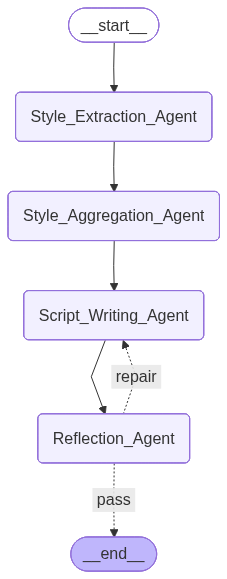

In [68]:
# Visualize the graph 
Image(app.get_graph().draw_mermaid_png())

# Example Run

In [69]:
# Simulate this by loading the mock data json
with open("mocks/mock_content_blueprint.json", "r") as f:
    content_outline = json.load(f)

pprint(content_outline)

{'big_idea': 'Artificial intelligence will be a defining technology of our '
             'era, and Singapore must harness it to raise productivity, '
             'strengthen competitiveness, and create better opportunities for '
             'all Singaporeans.',
 'hook': {'description': 'Open by highlighting how AI has rapidly evolved from '
                         'a distant concept to an integral part of everyday '
                         'life in Singapore, touching on familiar examples '
                         "that resonate with the audience's experience today, "
                         'setting the stage for why this matters to all '
                         'Singaporeans now and in the future, especially at '
                         'this National Day Rally moment of reflection and '
                         'progress discussion.',
          'type': 'observation'},
 'ted_sections': [{'id': 'TS1',
                   'must_include_facts': ['In 2020, AI struggled to solve '

In [70]:
# Mock initial state
initial_state = {
    "content_blueprint": content_outline,
    "chunk_style_notes": [],
    "style_profile": {},
    "stylistic_script": "",
    "style_feedback": None,
    "style_approved": False,
    "style_reviews": 0
}

In [ ]:
# if __name__ == "__main__":
#     result = app.invoke(initial_state)

#     print("\n=== FINAL SPEECH ===\n")
#     print(result["stylistic_script"])

In [71]:
# Just run directly no need if __name___... for now
result = app.invoke(initial_state)


========STYLE EXTRACTION AGENT ========
Extracting style from chunk 1/14...
chunk 1: RALLY, HELD AT FULLERTON SQUARE, ON 20TH DECEMBER, 1976

Friends and fellow-citizens,

If you read, and your understand only the English Language, then you are at a very grave disadvantage because you really don’t know what is going on in a large part of Singapore . If you believe that the Straits Times and the New Nation is what Singapore is about, then you are living in a dream world.

chunk_style: {'tone': ['authoritative', 'direct', 'urgent', 'serious', 'engaging'], 'avoid': ['motivational slogans', 'corporate buzzwords', 'sentimental phrasing', 'ironic tone', 'abstract language'], 'lexical_preferences': ['plainspoken vocabulary', 'concrete nouns', 'colloquial expressions', 'national references', 'simple negations'], 'syntax': ['short declarative sentences', 'direct address', 'conditional clauses', 'contrasting statements', 'informal contractions'], 'rhetorical_devices': ['direct audience address'

## Archived: Previous Runs
Previously checking on the maker-checker loop

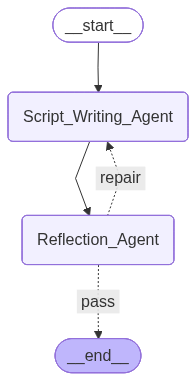

In [181]:
grapht = StateGraph(SpeechScriptState)

grapht.add_node("Script_Writing_Agent", Script_Writing_Agent)
grapht.add_node("Reflection_Agent", Reflection_Agent)

grapht.add_edge(START, "Script_Writing_Agent")
grapht.add_edge("Script_Writing_Agent", "Reflection_Agent")

grapht.add_conditional_edges(
    "Reflection_Agent", 
    route_after_reflection_check,
    {
        "pass": END, # Go to Judging Agent 
        "repair": "Script_Writing_Agent"
    }
)

appt = grapht.compile()
Image(appt.get_graph().draw_mermaid_png())

In [137]:
intermediate_result = deepcopy(result_2)

In [183]:
result_2 = appt.invoke(result_2)


========SCRIPT WRITING AGENT ========
is_revision status: False
Script Draft: Good evening, fellow Singaporeans.

Not long ago, artificial intelligence was something we read about in science fiction or discussed in far-off tech labs. Today, it’s right here with us, woven into our daily lives. Think about how many of you use AI to plan your holidays—getting personalised travel recommendations and itineraries tailored just for you. Even in our public service, AI is hard at work. In agency call centres, it transcribes conversations in all four official languages and creates summaries so officers can spend more time helping you directly. Just a few years back—in 2020—AI couldn’t even solve basic math problems reliably. Now, by 2025, it can compete in the International Math Olympiad and perform at a gold medal level. That’s a leap that shows how fast this technology is moving.

So AI is no longer something distant or theoretical. The real question for Singapore is how we harness it to stre

/usr/local/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ReflectionBlueprint(conte...e more dynamically.')])), input_type=ReflectionBlueprint])
  return self.__pydantic_serializer__.to_python(


style_feedback:
{'content_issues': {'big_idea': 'The big idea is stated but lacks emphasis on '
                                'creating better opportunities for all '
                                'Singaporeans as a key outcome of harnessing '
                                'AI.',
                    'hook': {'description': 'The hook does not explicitly set '
                                            'the stage for why AI matters to '
                                            'all Singaporeans now and in the '
                                            'future, especially at this '
                                            'National Day Rally moment of '
                                            'reflection and progress '
                                            'discussion.',
                             'type': 'observation'},
                    'ted_sections': [{'id': 'TS1',
                                      'must_include_facts': [{'issue': 'Fact '
            

# Independent Evaluation Pipeline

The system includes a Reflection Agent used to give targeted feedback during generation-time revision. Separately, we have an independent evaluation pipeline outside the LangGraph loop. 

The project requirement is not only to evaluate the final result (via the Judging Agent) but also the process. We need to check if the steps, tools, etc were correct and efficient. In this process, the key questions circle around whether the output is in the correct format, and whether it is useful for the next step:

Style Extraction Agent
* Did the agent produce notes in the expected schema? (correctness)
* Did the notes actually reflect style characteristics? (usefulness)

Style Aggregation Agent
* Did it summarise the style chunk notes correctly? (usefulness)

Script Writing Agent
* Did it follow the outline format? (correctness)
* Did it follow the style profile given? (correctness)

Reflection Agent
* Precision: Of the items it flagged, how many were truly issues?

**Approach**

Style Extraction Agent
* Schema validity rate: `valid_outputs / total_outputs`
* Usefulness score: LLM judge to output an intermediate quality score (scale of 1-5)

Style Aggregation Agent
* Manually compile top styles per aspect, then see if the LLM managed to catch those top styles in their 6 options provided per style

Script Writing Agent
* Outline coverage score: Flatten the nested JSON content_outline, only include `must_include_points` and `must_include_facts`. `items covered / total items`.
* `Style_profile` fidelity: LLM judge to output an intermediate quality score (scale of 1-5)

Reflection Agent
* Compute precision: `true_issues_flagged` / `total_issues_flagged`

Output can be JSON with the score and reason
```json
{
  "score": 4,
  "reason": "Notes capture tone and rhetorical patterns clearly."
}
```

For the quality / usefulness scores on a scale of 1 to 5, rubrics and their definitions will be individually defined in the user_prompts

In [6]:
# Simulate this by loading the mock data json
with open("mocks/mock_content_blueprint.json", "r") as f:
    content_outline = json.load(f)

pprint(content_outline)

{'big_idea': 'Artificial intelligence will be a defining technology of our '
             'era, and Singapore must harness it to raise productivity, '
             'strengthen competitiveness, and create better opportunities for '
             'all Singaporeans.',
 'hook': {'description': 'Open by highlighting how AI has rapidly evolved from '
                         'a distant concept to an integral part of everyday '
                         'life in Singapore, touching on familiar examples '
                         "that resonate with the audience's experience today, "
                         'setting the stage for why this matters to all '
                         'Singaporeans now and in the future, especially at '
                         'this National Day Rally moment of reflection and '
                         'progress discussion.',
          'type': 'observation'},
 'ted_sections': [{'id': 'TS1',
                   'must_include_facts': ['In 2020, AI struggled to solve '

In [73]:
# Create a simple JSON schema (no need Pydantic)
schema = {
    "title": "evaluation",
    "type": "object",
    "properties": {
        "score": {"type": "integer"},
        "reason": {"type": "string"}
    },
    "required": ["score", "reason"]
}

## Style Extraction Agent Process Evaluation

**Step 1: Schema Validity**  
Validate against pydantic schema

In [43]:
# Compute schema validity
chunk_style_notes_output = result["chunk_style_notes"] # Extract chunk_style_notes from the above run
total_outputs = len(chunk_style_notes_output)

valid_outputs = 0
invalid_outputs = 0
invalid_output_indices = []

for i, note in enumerate(chunk_style_notes_output):
    try:
        StyleProfileStructure.model_validate_json(json.dumps(note)) # convert back from Python dict to JSON
        valid_outputs += 1
    except ValidationError:
        invalid_outputs += 1
        invalid_output_indices.append(i)

schema_validity_rate = valid_outputs / total_outputs if total_outputs > 0 else 0.0

print("valid_outputs:", valid_outputs)
print("invalid_outputs:", invalid_outputs)
print("invalid_indices:", invalid_output_indices)
print("schema_validity_rate:", schema_validity_rate)

valid_outputs: 14
invalid_outputs: 0
invalid_indices: []
schema_validity_rate: 1.0


**Step 2: Usefulness of Style Notes per Chunk**  
Use LLM as a Judge to score how well the style notes match up to the chunk of text

In [44]:
style_ext_eval_sys_pmpt = """
You are an impartial evaluation model. Follow the instructions strictly.
"""

In [63]:
def build_style_ext_eval_user_pmpt(chunk, chunk_style_notes):
    return f"""
Evaluate whether the style notes accurately describe the speaking style in the speech excerpt.

Check whether the stylistic observations in the style notes can be logically inferred from the excerpt. Focus only on *how* the speaker communicates, not the topic.

Rules:
- Only give high scores if the notes are clearly supported by specific evidence in the excerpt.
- If a claim in the notes is not visible in the excerpt, it should lower the score.
- When uncertain, prefer the lower score.
- Explanation must be concise (maximum 5 sentences).

Scoring:
1 = Not supported by the excerpt
3 = Partially supported or vague
5 = Clearly supported and well-reflected
Use 2 or 4 if the match is between levels.

Speech excerpt:
\"\"\"
{chunk}
\"\"\"

Style notes:
{chunk_style_notes}

Return:
- score (1–5)
- reason (brief explanation citing evidence or missing support)
"""

In [64]:
# Compute usefulness score
# output a usefulness score per comparison
# collect all the scores and average them

# Extract chunks .txt files and sort in order to match with chunk_style_notes
chunks_folder = Path("data/samples_chunks")
files = sorted(
    chunks_folder.glob("*.txt"),
    key=lambda x: int(x.stem.split("_")[-1])  # extract number
)
chunks_texts = []
for file in files:
    with open(file, "r", encoding="utf-8") as f:
        chunks_texts.append(f.read())

# init LLM
style_ext_eval_llm = ChatOpenAI(
    model="gpt-4.1-mini", 
    temperature=0
).with_structured_output(schema)

usefulness_scores = []
# Loop through each chunk, chunk notes to get a score
for c, cn in zip(chunks_texts, result["chunk_style_notes"]):
    score_obj = style_ext_eval_llm.invoke([
            SystemMessage(content=style_ext_eval_sys_pmpt),
            HumanMessage(
                content=build_style_ext_eval_user_pmpt(
                    chunk=c, 
                    chunk_style_notes=cn
                )
            )
        ])
    print(score_obj)
    usefulness_scores.append(score_obj)

{'score': 5, 'reason': "The excerpt uses direct audience address ('Friends and fellow-citizens'), short declarative sentences, and a serious, authoritative tone. It challenges prevailing beliefs ('If you believe... then you are living in a dream world'), showing a confrontational and engaging style. The vocabulary is plainspoken and concrete, avoiding jargon or sentimental phrasing. These elements clearly support the style notes provided."}
{'score': 5, 'reason': "The style notes are clearly supported by the excerpt: the tone is combative and confrontational (e.g., 'I smack you because it can lead to bloodshed'), the speaker uses colloquial and informal vocabulary ('smacked down very hard'), and the syntax includes long sentences with parenthetical insertions ('or as Mr. Jeyaretnam hopes...'). Rhetorical devices like direct audience address ('Before you even pretend...'), contrast framing ('He was saying one thing; his banners...'), and rhetorical questions ('I don’t know whether I sha

In [65]:
# Compute average usefulness score
avg_score = sum(item['score'] for item in usefulness_scores) / len(usefulness_scores)
print(avg_score)

5.0


In [62]:
# Manually check against the text and see if the LLM's analysis makes sense
for c, t in zip(chunks_texts, result["chunk_style_notes"]):
    print("CHUNK:", c)
    print("\n\nSTYLE NOTES:", t)

CHUNK: RALLY, HELD AT FULLERTON SQUARE, ON 20TH DECEMBER, 1976

Friends and fellow-citizens,

If you read, and your understand only the English Language, then you are at a very grave disadvantage because you really don’t know what is going on in a large part of Singapore . If you believe that the Straits Times and the New Nation is what Singapore is about, then you are living in a dream world.


STYLE NOTES: {'tone': ['authoritative', 'direct', 'urgent', 'serious', 'engaging'], 'avoid': ['motivational slogans', 'corporate buzzwords', 'sentimental phrasing', 'ironic tone', 'complex jargon'], 'lexical_preferences': ['plainspoken vocabulary', 'concrete nouns', 'colloquial expressions', 'repeated key terms', 'simple adjectives'], 'syntax': ['short declarative sentences', 'direct address', 'conditional clauses', 'simple sentence structures', 'occasional rhetorical questions'], 'rhetorical_devices': ['direct audience address', 'contrast framing', 'anaphora', 'rhetorical questions', 'appeals 

## Style Aggregation Agent Process Evaluation

Manually compile the style attributes and take the top 6 in each aspect. Check if the LLM had included any of these top 6 inside the style_profile.

In [69]:
# Tally top style attributes from chunk_style_notes
# This is what a human would do manually

from collections import defaultdict, Counter
tally = defaultdict(Counter)

for note in result["chunk_style_notes"]:
    for aspect, phrases in note.items():
        tally[aspect].update(p.lower() for p in phrases)

for aspect, counter in tally.items():
    print(f"\n{aspect}")
    for attr, count in counter.most_common(6):
        print(f"  {attr}: {count}")


tone
  direct: 9
  authoritative: 7
  pragmatic: 7
  informal: 6
  reflective: 6
  slightly confrontational: 4

avoid
  motivational slogans: 14
  corporate buzzwords: 14
  sentimental phrasing: 14
  abstract language: 4
  overly formal diction: 3
  abstract generalizations: 3

lexical_preferences
  colloquial expressions: 14
  concrete nouns: 12
  plainspoken vocabulary: 7
  repeated key terms: 6
  idiomatic phrases: 3
  informal vocabulary: 2

syntax
  parenthetical insertions: 10
  rhetorical questions: 7
  short declarative sentences: 6
  parallel constructions: 6
  direct quotations: 5
  contrasting clauses: 3

rhetorical_devices
  contrast framing: 14
  direct audience address: 12
  rhetorical questions: 8
  repetition for emphasis: 6
  anaphora: 5
  anecdotal references: 3

argument_structure
  blunt issue naming: 13
  example-driven reasoning: 12
  problem–consequence framing: 8
  escalation through concrete examples: 6
  anticipation of objections: 4
  historical references: 

In [67]:
result["style_profile"]

{'tone': ['authoritative',
  'direct',
  'pragmatic',
  'slightly confrontational',
  'informal',
  'reflective'],
 'avoid': ['motivational slogans',
  'corporate buzzwords',
  'sentimental phrasing',
  'abstract language',
  'overly formal language',
  'complex jargon'],
 'lexical_preferences': ['plainspoken vocabulary',
  'concrete nouns',
  'colloquial expressions',
  'repeated key terms',
  'specific figures and statistics',
  'proper names and idiomatic phrases'],
 'syntax': ['short declarative sentences',
  'rhetorical questions',
  'parenthetical insertions',
  'parallel constructions',
  'contrasting clauses',
  'sentence fragments'],
 'rhetorical_devices': ['direct audience address',
  'contrast framing',
  'anaphora',
  'rhetorical questions',
  'repetition for emphasis',
  'anecdotal references'],
 'argument_structure': ['blunt issue naming',
  'problem–consequence framing',
  'example-driven reasoning',
  'escalation through concrete examples',
  'anticipation of objections

In [78]:
# Check if the LLM's attributes mentioned per aspect are inside the top 6 styles

# Store top N aspects in a new variable
top_attrs = {}
for aspect, counter in tally.items():
    top_attrs[aspect] = [attr for attr, count in counter.most_common(6)]

# Tally how many LLM's attributes were part of the top 6 styles
style_agg_results = {}
for aspect, attrs in result["style_profile"].items():
    in_top_attrs = sum(attr in top_attrs[aspect] for attr in attrs)
    style_agg_results[aspect] = f"{in_top_attrs}/{len(attrs)})"

print(style_agg_results)

{'tone': '6/6)', 'avoid': '4/6)', 'lexical_preferences': '4/6)', 'syntax': '5/6)', 'rhetorical_devices': '6/6)', 'argument_structure': '5/6)', 'audience_relationship': '5/6)'}


Can be seen that LLM hallucinated some of the attributes in the `style_profile`

## Script Writing Agent Process Evaluation

**Section 1: Check Coverage Percentage**  
Use LLM to identify the no. of points and facts from the outline that were covered  
Then programmatically compute the coverage percent.

In [14]:
# Import schemas
from schemas.script_eval import ScriptEvaluation

In [6]:
# Export script drafts
speech_drafts_folder = Path("data/speech_drafts")
files = sorted(speech_drafts_folder.glob("*.txt"))
draft_texts = []
for file in files:
    with open(file, "r", encoding="utf-8") as f:
        draft_texts.append(f.read())

In [7]:
# Filter the content_outline JSON to only include purpose, must_include_points and must_include_facts
filtered_outline = [
    {
        "section_id": section["id"],
        "section_purpose": section["purpose"],
        "must_include_points": section.get("must_include_points", []),
        "must_include_facts": section.get("must_include_facts", [])
    }
    for section in content_outline.get("ted_sections", [])
]

pprint(filtered_outline)

[{'must_include_facts': ['In 2020, AI struggled to solve basic math problems '
                         'reliably, but by 2025 it could compete in the '
                         'International Math Olympiad and achieve a gold '
                         'medal-level performance',
                         'AI is already widely used by Singaporeans, including '
                         'for travel planning where it can recommend '
                         'destinations and generate personalised itineraries',
                         "In Singapore's civil service, AI is used in agency "
                         'call centres to transcribe conversations in all four '
                         'official languages and generate summaries so '
                         'officers can focus on serving the public'],
  'must_include_points': [],
  'section_id': 'TS1',
  'section_purpose': 'Introduce AI as a defining technology that is rapidly '
                     'advancing and already transforming

In [35]:
# Convert ground truth outline (filtered_outline) to tally also
outline_tally = []
for section in filtered_outline:
    outline_tally.append({
            "id": section["section_id"],
            "num_matched_facts": len(section["must_include_facts"]),
            "num_matched_points": len(section["must_include_points"])
    })

pprint(outline_tally)

[{'id': 'TS1', 'num_matched_facts': 3, 'num_matched_points': 0},
 {'id': 'TS2', 'num_matched_facts': 3, 'num_matched_points': 2},
 {'id': 'TS3', 'num_matched_facts': 2, 'num_matched_points': 1},
 {'id': 'TS4', 'num_matched_facts': 2, 'num_matched_points': 3},
 {'id': 'TS5', 'num_matched_facts': 0, 'num_matched_points': 3}]


In [8]:
script_eval_sys_pmpt = """
You are an impartial evaluation model. Follow the instructions strictly.
"""

In [15]:
def build_script_eval_user_pmpt(filtered_outline, speech_draft):
    return f"""
You are evaluating whether a speech draft covers the required content in a content outline.

Task:
For each section in the content outline:
1. Identify the part(s) of the speech draft that best match the section_purpose.
2. Check which must_include_facts and must_include_points are present in those parts.

Instructions:
- Use the content_outline structure as the template for your JSON output.
- For each section, include only the facts and points that are found in the speech draft.
- If a fact or point is not found, omit it entirely from the JSON.
- Treat paraphrased or equivalent meaning as a valid match.
- When uncertain, do not include the item.
- Use the exact original strings from content_outline (no rewriting or summarising).
- Do not force a 1:1 mapping between sections and paragraphs.

Content outline:
{json.dumps(filtered_outline, ensure_ascii=False, indent=2)}

Speech draft:
\"\"\"
{speech_draft}
\"\"\"
"""

In [19]:
# Init LLM to compute items covered in the script / total items.
script_eval_llm = ChatOpenAI(
    model="gpt-4.1-mini", 
    temperature=0
).with_structured_output(ScriptEvaluation)

coverage_objects = []
# Loop through each draft, compare with the filtered_content outline to check the points that were covered
for d in draft_texts:
    coverage_obj = script_eval_llm.invoke([
            SystemMessage(content=script_eval_sys_pmpt),
            HumanMessage(
                content=build_script_eval_user_pmpt(
                    filtered_outline=filtered_outline, 
                    speech_draft=d
                )
            )
        ])
    dumped = coverage_obj.model_dump(mode="json")
    coverage_objects.append(dumped)

In [25]:
# See a sample of the output per draft
pprint(coverage_objects[0]['eval_sections'])

[{'id': 'TS1',
  'matched_facts': ['In 2020, AI struggled to solve basic math problems '
                    'reliably, but by 2025 it could compete in the '
                    'International Math Olympiad and achieve a gold '
                    'medal-level performance',
                    'AI is already widely used by Singaporeans, including for '
                    'travel planning where it can recommend destinations and '
                    'generate personalised itineraries',
                    "In Singapore's civil service, AI is used in agency call "
                    'centres to transcribe conversations in all four official '
                    'languages and generate summaries so officers can focus on '
                    'serving the public'],
  'matched_points': []},
 {'id': 'TS2',
  'matched_facts': ['AI is being combined with robotics and autonomous '
                    'machines at Tuas Port and studied for automation at '
                    'Changi Airport',


In [26]:
# Compute the no. of matched_points and matched_facts in each draft
coverage_tallies = []
for obj in coverage_objects:
    tally = []
    for section in obj["eval_sections"]:
        tally.append({
            "id": section["id"],
            "num_matched_facts": len(section["matched_facts"]),
            "num_matched_points": len(section["matched_points"])
        })
    coverage_tallies.append(tally)

In [27]:
# See how the output looks like
coverage_tallies

[[{'id': 'TS1', 'num_matched_facts': 3, 'num_matched_points': 0},
  {'id': 'TS2', 'num_matched_facts': 3, 'num_matched_points': 2},
  {'id': 'TS3', 'num_matched_facts': 2, 'num_matched_points': 1},
  {'id': 'TS4', 'num_matched_facts': 2, 'num_matched_points': 3},
  {'id': 'TS5', 'num_matched_facts': 0, 'num_matched_points': 3}],
 [{'id': 'TS1', 'num_matched_facts': 3, 'num_matched_points': 0},
  {'id': 'TS2', 'num_matched_facts': 3, 'num_matched_points': 2},
  {'id': 'TS3', 'num_matched_facts': 2, 'num_matched_points': 1},
  {'id': 'TS4', 'num_matched_facts': 2, 'num_matched_points': 3},
  {'id': 'TS5', 'num_matched_facts': 0, 'num_matched_points': 3}],
 [{'id': 'TS1', 'num_matched_facts': 3, 'num_matched_points': 0},
  {'id': 'TS2', 'num_matched_facts': 3, 'num_matched_points': 2},
  {'id': 'TS3', 'num_matched_facts': 2, 'num_matched_points': 1},
  {'id': 'TS4', 'num_matched_facts': 2, 'num_matched_points': 3},
  {'id': 'TS5', 'num_matched_facts': 0, 'num_matched_points': 3}]]

In [38]:
# Compute overall outline tally per draft
total_in_outline = sum(s['num_matched_facts'] for s in outline_tally) + sum(s['num_matched_points'] for s in outline_tally)

for draft_tally in coverage_tallies:
    items_covered = sum(s['num_matched_facts'] for s in draft_tally) + sum(s['num_matched_points'] for s in draft_tally)
    print(f"coverage percent: {items_covered}/{total_in_outline}")

coverage percent: 19/19
coverage percent: 19/19
coverage percent: 19/19


The script contains all the required points and facts

**Section 2: Check `style_profile` fidelity**  
Use LLM as a judge approach, judge on a scale of 1 to 5

In [72]:
voice_eval_sys_pmpt = """
You are an impartial evaluation model. Follow the instructions strictly.
"""

In [74]:
def build_voice_eval_user_pmpt(style_profile, speech_draft):
    return f"""
You are evaluating STYLE MATCH only.

Task:
Assess how closely the speech draft matches the speaking style described in the Style Profile.

Instructions:
- Evaluate only stylistic alignment, not whether the speech is good, accurate, persuasive, or well-structured unless those qualities are explicitly part of the style profile.
- Base your judgment on observable signals in the draft.
- Compare the draft against the profile traits. Do not infer style traits that are not stated or strongly implied.
- If the profile includes multiple traits, consider the overall balance, not just one matching trait.

Scoring rubric:
1 = Very poor match; the described style is mostly absent or contradicted
2 = Weak match; a few traits appear, but most are missing
3 = Partial match; some important traits are evident, others are missing or inconsistent
4 = Strong match; most important traits are present with minor gaps
5 = Excellent match; the style is clearly and consistently reflected

Speech draft:
\"\"\"
{speech_draft}
\"\"\"

Style Profile:
\"\"\"
{style_profile}
\"\"\"
"""

In [76]:
# Init LLM 
voice_eval_llm = ChatOpenAI(
    model="gpt-4.1-mini", 
    temperature=0
).with_structured_output(schema)

fidelity_scores = []
# Loop through each draft, compare with style_profile to check if the user's voice is present
for d in draft_texts:
    score_obj = voice_eval_llm.invoke([
            SystemMessage(content=voice_eval_sys_pmpt),
            HumanMessage(
                content=build_voice_eval_user_pmpt(
                    style_profile=result["style_profile"], 
                    speech_draft=d
                )
            )
        ])
    fidelity_scores.append(score_obj)

In [78]:
pprint(fidelity_scores)

[{'reason': 'The speech draft strongly reflects many key style traits from the '
            'profile. It uses plainspoken vocabulary, concrete nouns, and '
            'includes numerical data and historical references, aligning well '
            'with lexical preferences. The tone is authoritative, direct, '
            "pragmatic, and somewhat reflective, matching the profile's tone "
            'traits. The speech employs rhetorical questions, direct audience '
            'address, contrast framing, and example-driven reasoning, '
            'consistent with the rhetorical devices and argument structure '
            'specified. Syntax includes short declarative sentences and some '
            'parenthetical insertions, though sentence fragments and abrupt '
            'pivots are less evident. The speech avoids motivational slogans, '
            'corporate buzzwords, sentimental or overly formal language, '
            'adhering to the avoidance criteria. However, the style

In [79]:
# Compute average fidelity score
fidelity_avg_score = sum(item['score'] for item in fidelity_scores) / len(fidelity_scores)
print(fidelity_avg_score)

4.333333333333333


Can see that the style fidelity scores progressively improve

## Reflection Agent Process Evaluation

Precision: Of the items it flagged, how many were truly issues?  
Check the latest evaluation as an indication of the quality of this agent.

In [96]:
ref_eval_sys_pmpt = """
You are an impartial evaluation model. Follow the instructions strictly.
"""

In [106]:
def build_ref_eval_user_pmpt(style_feedback):
    return f"""
You are evaluating the precision of a Reflection Agent.

The Reflection Agent was explicitly instructed to raise ISSUES ONLY.
Your job is to judge whether the items in its output are actually issues.

Definitions:
- A true issue is a statement that identifies a genuine problem, omission, weakness, ambiguity, unsupported claim, unmet requirement, or deficiency.
- A non-issue is a statement that says something is fine, adequate, present, clear, within budget, met, or otherwise not problematic.
- Neutral observations, praise, confirmations, and status updates are also non-issues.
- An ambiguous item is unclear or borderline. Treat ambiguous items as NOT true issues when computing precision.

What counts as an evaluative item:
Any output statement that assesses a part of the draft, including top-level fields and section-level fields such as purpose, narrative_role, transition_out, word_budget, and issue descriptions.

Task:
1. Read the Reflection Agent output.
2. Count every evaluative item it produced.
3. Classify each as one of:
   - true_issue
   - non_issue
   - ambiguous
4. Compute:
   - total_flagged_items
   - true_issues
   - non_issues
   - ambiguous_items
   - precision = true_issues / total_flagged_items
5. Be strict. If an item says something is adequately covered, present, clear, met, or within budget, treat it as a non-issue.

Return ONLY in this format:

total_flagged_items: <number>
true_issues: <number>
non_issues: <number>
ambiguous_items: <number>
precision: <number between 0 and 1>
reason: <brief explanation in 2-4 sentences>

Additionally, list ALL items classified as non_issue.
non_issue_items:
- <item>
- <item>
...

Reflection Agent output:
{style_feedback}
"""

In [107]:
# Init LLM 
ref_eval_llm = ChatOpenAI(
    model="gpt-4.1-mini", 
    temperature=0
)

# Break down the feedback and let LLM evaluate part by part so it is not overwhelmed
content_issues = result["style_feedback"]["content_issues"]
style_issues = result["style_feedback"]["style_issues"]

# Review content_issues
content_eval_result = ref_eval_llm.invoke([
    SystemMessage(content=ref_eval_sys_pmpt),
    HumanMessage(content=build_ref_eval_user_pmpt(style_feedback=content_issues))
])
# Review style_issues
style_eval_result = ref_eval_llm.invoke([
    SystemMessage(content=ref_eval_sys_pmpt),
    HumanMessage(content=build_ref_eval_user_pmpt(style_feedback=style_issues))
])

The results vary, it's not very deterministic, but doesnt vary too much.  
Can be considered a rough gauge when I manually checked, coz if human check it is too tedious.

In [108]:
print(content_eval_result.content)

total_flagged_items: 29
true_issues: 19
non_issues: 10
ambiguous_items: 0
precision: 0.655
reason: The Reflection Agent output contains multiple evaluative statements, many of which identify genuine weaknesses such as lack of emphasis, insufficient detail, or unclear links to AI, which qualify as true issues. Several items explicitly state that aspects are adequately covered, present, clear, or within budget, which are non-issues. No ambiguous items were found. The precision reflects the proportion of true issues among all flagged evaluative items.

non_issue_items:
- Narrative role is adequately covered.
- Narrative role is adequately covered.
- Narrative role is adequately covered.
- Narrative role is adequately covered.
- Narrative role is adequately covered.
- Transition out is present and clear.
- Transition out is present and clear.
- Transition out is present and clear.
- Transition out is present and clear.
- Word count is within budget.


In [94]:
result["style_feedback"]["content_issues"]

{'hook': {'type': 'observation',
  'description': "Open by highlighting how AI has rapidly evolved from a distant concept to an integral part of everyday life in Singapore, touching on familiar examples that resonate with the audience's experience today, setting the stage for why this matters to all Singaporeans now and in the future, especially at this National Day Rally moment of reflection and progress discussion."},
 'big_idea': 'Big idea is stated but not explicitly emphasized as the defining technology of our era or linked clearly to raising productivity, competitiveness, and opportunities for all Singaporeans.',
 'ted_sections': [{'id': 'TS1',
   'purpose': 'Purpose is generally met but could be clearer in introducing AI as a defining technology rapidly advancing and transforming daily life and public services.',
   'narrative_role': 'Narrative role is adequately covered.',
   'must_include_facts': [{'item': "In Singapore's civil service, AI is used in agency call centres to tra

In [102]:
print(style_eval_result.content)

total_flagged_items: 7
true_issues: 7
non_issues: 0
ambiguous_items: 0
precision: 1.0
reason: All items identify genuine problems or weaknesses in the draft, such as lack of clarity, insufficient balance, minimal references, or potential negative effects on audience engagement. None of the items state that something is adequate, present without issue, or otherwise non-problematic. Therefore, all are true issues.

non_issue_items:



In [95]:
result["style_feedback"]["style_issues"]

{'argument_structure': [{'item': 'example-driven reasoning',
   'issue': "Examples are present but some lack explicit connection to the argument's escalation."}],
 'audience_relationship': [{'item': 'challenging opposition',
   'issue': 'Direct challenge to doubters is present but could be more balanced to maintain inclusive engagement.'}],
 'avoid': [{'item': 'motivational slogans',
   'issue': "Use of 'dynamic economy' as a buzzword without clear definition."}],
 'lexical_preferences': [{'item': 'historical and political references',
   'issue': 'Historical references are included but political references are minimal.'}],
 'rhetorical_devices': [{'item': 'anecdotal references',
   'issue': 'Anecdotal references are present but could be more vivid or personal.'}],
 'syntax': [{'item': 'sentence fragments',
   'issue': 'Some sentence fragments reduce clarity and disrupt flow.'}],
 'tone': [{'item': 'slightly confrontational',
   'issue': 'Tone is slightly confrontational but could risk